# Autonomous Text-to-SQL Agent with LangGraph & Groq

Welcome to the **Autonomous Text-to-SQL Agent** project! This notebook implements an end-to-end, production-ready yet student-friendly AI agent that translates natural language questions into executable SQLite queries, validates them against security rules, executes them safely, self-corrects if syntax or runtime errors occur, and returns both formatted tabular results and plain-English explanations.

---

## 1. What is Text-to-SQL?
**Text-to-SQL** is a transformative application of Natural Language Processing (NLP) and Large Language Models (LLMs). It allows users—such as business analysts, product managers, or executives—to interrogate relational databases using everyday language (e.g., *"Which country generated the most revenue?"*) without writing SQL by hand.

The AI system:
1. Translates human intent into structured database queries.
2. Navigates relational schemas, tables, and foreign keys.
3. Retrieves relevant data and presents it back in natural, understandable summaries.

---

## 2. What This Project Accomplishes
In this notebook, we construct an **Autonomous Agent** powered by:
- **Groq LLM**: Ultra-fast LLM inference via `langchain-groq`.
- **SQLite**: Local relational database engine querying the well-known **Chinook** music store dataset.
- **LangGraph**: State machine orchestrating schema loading, query generation, validation, execution, error routing, and autonomous self-correction.
- **Security Guardrails**: Strict AST/regex validation allowing only safe, single `SELECT` statements while neutralizing SQL injection and destructive commands (`DROP`, `DELETE`, `UPDATE`, etc.).
- **Autonomous Self-Correction**: When an error occurs (e.g., misspelled column or invalid join), the agent catches the error, reflects on the diagnostic message, regenerates a corrected query, and retries automatically (capped at 3 attempts).
- **Data Visualization**: Automatic generation of Matplotlib bar, horizontal bar, and pie charts for visual insights.

---

## 3. Agent Pipeline Architecture
```
                     +---------------------------+
                     |    User Asks Question     |
                     +---------------------------+
                                   |
                                   v
                     +---------------------------+
                     | 1. Dynamic Schema Loader  |
                     +---------------------------+
                                   |
                                   v
                     +---------------------------+
                     | 2. SQL Generator (LLM)    |
                     +---------------------------+
                                   |
                                   v
                     +---------------------------+
                     |   3. Security Validator   |  ---(Invalid/Dangerous)---> [Self-Correction]
                     +---------------------------+                                     |
                                   | (Valid)                                           |
                                   v                                                   |
                     +---------------------------+                                     |
                     |     4. SQL Execution      |                                     |
                     +---------------------------+                                     |
                                   |                                                   |
                 +-----------------+-----------------+                                 |
                 |                                   |                                 |
           (Execution OK)                     (Execution Error)                        |
                 |                                   |                                 |
                 v                                   v                                 |
     +-----------------------+           +-----------------------+                     |
     | 5. Answer Generation  |           | 6. Self-Correction    |<--------------------+
     +-----------------------+           | (LLM + Error Feedback)|
                 |                       +-----------------------+
                 v                                   | (Attempts < 3)
     +-----------------------+                       |
     |  Visualizations &     |<----------------------+ (Loop back to Validator)
     |  Final Response       |
     +-----------------------+ (If Attempts >= 3: Graceful Exit)
                 |
                 v
               [END]
```
Let's begin step by step!

---
## Section 2 - Imports and Configuration

In this section, we import all essential libraries:
- **`os` & `re`**: File system operations and regular expressions for SQL parsing.
- **`sqlite3`**: SQLite database connection and metadata exploration.
- **`typing`**: Python type hints (`TypedDict`, `Optional`, `List`, `Dict`, `Any`, `Tuple`) for robust code.
- **`pandas`**: High-performance data manipulation and DataFrame formatting.
- **`matplotlib.pyplot`**: Visual analytics and charting.
- **`dotenv`**: Securely loading environment variables from `.env`.
- **`langchain_groq`**: Interface to Groq's high-speed Llama / Qwen inference API.
- **`langgraph.graph`**: StateGraph orchestrator for state machine nodes and conditional routing.

We also establish centralized configuration variables so model parameters and database paths can be updated in one place.

In [1]:
# Core Standard Library Imports
import os
import re
import sys
import sqlite3
from typing import TypedDict, Optional, List, Dict, Any, Tuple

# Third-Party Data & Visualization Libraries
import pandas as pd
import matplotlib.pyplot as plt

# Environment & LangChain Ecosystem
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

# Load Environment Variables from .env file
load_dotenv(override=True)

# Centralized Project Configuration
DB_PATH: str = "data/Chinook_Sqlite.sqlite"
GROQ_MODEL: str = "qwen/qwen3.8-27b"  # Fast, highly accurate SQL generation
MAX_RETRIES: int = 3

print("=" * 60)
print("CONFIGURATION SUMMARY")
print(f"Database Path : {DB_PATH}")
print(f"Groq Model    : {GROQ_MODEL}")
print(f"Max Retries   : {MAX_RETRIES}")
print(f"Database File Exists: {os.path.exists(DB_PATH)}")
print("=" * 60)

CONFIGURATION SUMMARY
Database Path : data/Chinook_Sqlite.sqlite
Groq Model    : qwen/qwen3.8-27b
Max Retries   : 3
Database File Exists: True


---
## Section 3 - Connect to SQLite

We establish a safe connection to `data/Chinook_Sqlite.sqlite` and verify that the SQLite engine can read the database without errors. We implement a fallback check in case the notebook is executed from a different working directory.

In [2]:
# Verify and connect to the SQLite database
actual_db_path = DB_PATH if os.path.exists(DB_PATH) else "Chinook_Sqlite.sqlite"

try:
    conn = sqlite3.connect(actual_db_path)
    cursor = conn.cursor()
    cursor.execute("SELECT sqlite_version();")
    version = cursor.fetchone()[0]
    print(f"Successfully connected to SQLite database at: {actual_db_path}")
    print(f"SQLite Engine Version: {version}")
    conn.close()
except Exception as e:
    print(f"Database connection error: {e}")

Successfully connected to SQLite database at: data/Chinook_Sqlite.sqlite
SQLite Engine Version: 3.53.2


---
## Section 4 - Inspect Database Tables

Relational databases maintain a metadata catalog. In SQLite, this is stored in `sqlite_master`.
Here, we query `sqlite_master` to dynamically list all user-created tables in the Chinook database (filtering out internal SQLite tracking tables starting with `sqlite_%`).

In [3]:
def list_database_tables(db_path: str = DB_PATH) -> List[str]:
    """
    Queries the SQLite catalog (sqlite_master) to retrieve all user table names.
    """
    target_path = db_path if os.path.exists(db_path) else "Chinook_Sqlite.sqlite"
    conn = sqlite3.connect(target_path)
    cursor = conn.cursor()
    cursor.execute("""
        SELECT name 
        FROM sqlite_master 
        WHERE type='table' AND name NOT LIKE 'sqlite_%'
        ORDER BY name;
    """)
    tables = [row[0] for row in cursor.fetchall()]
    conn.close()
    return tables

tables = list_database_tables(DB_PATH)
print(f"Discovered {len(tables)} tables in database:")
for idx, table in enumerate(tables, 1):
    print(f"  {idx:2d}. {table}")

Discovered 11 tables in database:
   1. Album
   2. Artist
   3. Customer
   4. Employee
   5. Genre
   6. Invoice
   7. InvoiceLine
   8. MediaType
   9. Playlist
  10. PlaylistTrack
  11. Track


---
## Section 5 - Inspect Database Schema Dynamically

> [!IMPORTANT]
> **No Hardcoded Schema**: Hardcoding a database schema makes code brittle and prevents it from adapting to schema migrations or new databases. 
> 
> We dynamically inspect the SQLite schema using:
> - `PRAGMA table_info(table_name)`: Extracts column names, data types, nullability, and primary key flags.
> - `PRAGMA foreign_key_list(table_name)`: Extracts explicit foreign key relationships connecting tables together.
>
> This creates a structured schema string that is provided to the LLM for accurate SQL generation.

In [4]:
def get_database_schema(db_path: str = DB_PATH) -> str:
    """
    Dynamically extracts the full schema of the SQLite database.
    Extracts table names, columns, data types, primary keys, and foreign keys.
    Does NOT hardcode any table or column names.
    """
    target_path = db_path if os.path.exists(db_path) else "Chinook_Sqlite.sqlite"
    conn = sqlite3.connect(target_path)
    cursor = conn.cursor()
    
    cursor.execute("""
        SELECT name FROM sqlite_master 
        WHERE type='table' AND name NOT LIKE 'sqlite_%'
        ORDER BY name;
    """)
    tables = [row[0] for row in cursor.fetchall()]
    schema_parts = []
    
    for tbl in tables:
        # 1. Extract Column Information
        cursor.execute(f"PRAGMA table_info({tbl});")
        cols = cursor.fetchall()
        # col tuple: (cid, name, type, notnull, dflt_value, pk)
        col_desc = [f"{col[1]} ({col[2] or 'TEXT'})" for col in cols]
        pk_cols = [col[1] for col in cols if col[5] > 0]
        
        # 2. Extract Foreign Key Relationships
        cursor.execute(f"PRAGMA foreign_key_list({tbl});")
        fks = cursor.fetchall()
        # fk tuple: (id, seq, table, from, to, on_update, on_delete, match)
        fk_desc = [f"FOREIGN KEY ({fk[3]}) REFERENCES {fk[2]}({fk[4]})" for fk in fks]
        
        col_summary = ", ".join(col_desc)
        tbl_info = f"Table: {tbl}\n  Columns: " + col_summary
        if pk_cols:
            pk_summary = ", ".join(pk_cols)
            tbl_info += f"\n  Primary Key: ({pk_summary})"
        if fk_desc:
            fk_summary = "\n    - ".join(fk_desc)
            tbl_info += "\n  Foreign Keys:\n    - " + fk_summary
            
        schema_parts.append(tbl_info)
        
    conn.close()
    return "\n\n".join(schema_parts)

# Extract and inspect schema
extracted_schema = get_database_schema(DB_PATH)
print("EXTRACTED DATABASE SCHEMA (First 1,200 characters):")
print("-" * 60)
print(extracted_schema[:1200] + "\n... [Truncated for preview] ...")

EXTRACTED DATABASE SCHEMA (First 1,200 characters):
------------------------------------------------------------
Table: Album
  Columns: AlbumId (INTEGER), Title (NVARCHAR(160)), ArtistId (INTEGER)
  Primary Key: (AlbumId)
  Foreign Keys:
    - FOREIGN KEY (ArtistId) REFERENCES Artist(ArtistId)

Table: Artist
  Columns: ArtistId (INTEGER), Name (NVARCHAR(120))
  Primary Key: (ArtistId)

Table: Customer
  Columns: CustomerId (INTEGER), FirstName (NVARCHAR(40)), LastName (NVARCHAR(20)), Company (NVARCHAR(80)), Address (NVARCHAR(70)), City (NVARCHAR(40)), State (NVARCHAR(40)), Country (NVARCHAR(40)), PostalCode (NVARCHAR(10)), Phone (NVARCHAR(24)), Fax (NVARCHAR(24)), Email (NVARCHAR(60)), SupportRepId (INTEGER)
  Primary Key: (CustomerId)
  Foreign Keys:
    - FOREIGN KEY (SupportRepId) REFERENCES Employee(EmployeeId)

Table: Employee
  Columns: EmployeeId (INTEGER), LastName (NVARCHAR(20)), FirstName (NVARCHAR(20)), Title (NVARCHAR(30)), ReportsTo (INTEGER), BirthDate (DATETIME), HireDa

---
## Section 6 - Test SQL Manually

To verify database integrity and pandas connectivity, we run 3 baseline queries:
1. Total customer count (`Customer` table).
2. Sample 5 invoices (`Invoice` table).
3. Sample 5 artists (`Artist` table).

In [5]:
actual_db_path = DB_PATH if os.path.exists(DB_PATH) else "Chinook_Sqlite.sqlite"
conn = sqlite3.connect(actual_db_path)

print("1. Total Customers Count:")
df_customers = pd.read_sql_query("SELECT COUNT(*) AS total_customers FROM Customer;", conn)
display(df_customers)

print("\n2. Sample Invoices (First 5):")
df_invoices = pd.read_sql_query("SELECT InvoiceId, CustomerId, InvoiceDate, BillingCountry, Total FROM Invoice LIMIT 5;", conn)
display(df_invoices)

print("\n3. Sample Artists (First 5):")
df_artists = pd.read_sql_query("SELECT ArtistId, Name FROM Artist LIMIT 5;", conn)
display(df_artists)

conn.close()

1. Total Customers Count:

2. Sample Invoices (First 5):

3. Sample Artists (First 5):


,total_customers
0,59


,InvoiceId,CustomerId,InvoiceDate,BillingCountry,Total
0,1,2,2021-01-01 00:00:00,Germany,1.98
1,2,4,2021-01-02 00:00:00,Norway,3.96
2,3,8,2021-01-03 00:00:00,Belgium,5.94
3,4,14,2021-01-06 00:00:00,Canada,8.91
4,5,23,2021-01-11 00:00:00,USA,13.86


,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains


---
## Section 7 - Initialize Groq LLM

We initialize `ChatGroq` from `langchain-groq`.
- **API Key**: Read securely from `.env` via `os.getenv("GROQ_API_KEY")`.
- **Temperature**: Set to `0` for deterministic, reproducible SQL query generation.
- **Max Tokens**: Set to `400` to prevent token overrun and comply with Groq rate limits while providing ample room for complex queries.
- **Graceful Error Handling**: If the API key is missing or placeholder, the code warns the user instead of crashing.

In [6]:
api_key = os.getenv("GROQ_API_KEY")

if not api_key or api_key == "your_groq_api_key_here":
    print("WARNING: GROQ_API_KEY is not configured in .env!")
    print("Please set GROQ_API_KEY in .env to enable LLM-driven features.")
    llm = None
else:
    try:
        llm = ChatGroq(
            model=GROQ_MODEL,
            temperature=0,
            max_tokens=400,
            api_key=api_key
        )
        test_response = llm.invoke("Say 'Groq connection verified!' in 3 words.")
        print(f"LLM Initialized Successfully!")
        print(f"Model: {GROQ_MODEL}")
        print(f"Health Check: {test_response.content.strip()}")
    except Exception as e:
        print(f"Error initializing ChatGroq: {e}")
        llm = None

LLM Initialized Successfully!
Model: qwen/qwen3.8-27b
Health Check: Connection verified!


---
## Section 8 - SQL Generation Prompt

A well-crafted prompt ensures the LLM adheres to database constraints:
1. **Schema Grounding**: Restrict tables and columns exclusively to those in the provided schema.
2. **Dialect Compliance**: Generate valid SQLite syntax (e.g. `LIMIT`, `strftime()`).
3. **Single Statement**: Enforce a single `SELECT` or `WITH ... SELECT` query.
4. **Zero Hallucination**: No invented table or column names.
5. **Clean Formatting**: Output raw SQL query without conversational filler.

In [7]:
def build_sql_generation_prompt(question: str, schema: str) -> str:
    """
    Constructs a disciplined system prompt for SQLite query generation.
    """
    return f"""You are an expert SQLite database engineer.
Given the SQLite database schema below, generate a single valid SQLite SELECT query to answer the user's question.

Rules:
1. Use ONLY the tables and columns present in the schema.
2. Generate ONLY one valid SELECT query (or WITH ... SELECT).
3. Do NOT hallucinate any table names, column names, or relationships.
4. Use proper SQL joins (JOIN ... ON) when needed based on foreign keys.
5. SQLite syntax rules: use LIMIT for top N, strftime for dates, etc.
6. Return ONLY the executable SQL query. Do not include conversational markdown, greetings, or explanations.

Database Schema:
{schema}

User Question: {question}

SQL Query:"""

sample_prompt = build_sql_generation_prompt("Show the top 3 best-selling albums.", extracted_schema[:350])
print("Sample Prompt Structure:\n" + "-" * 50)
print(sample_prompt)

Sample Prompt Structure:
--------------------------------------------------
You are an expert SQLite database engineer.
Given the SQLite database schema below, generate a single valid SQLite SELECT query to answer the user's question.

Rules:
1. Use ONLY the tables and columns present in the schema.
2. Generate ONLY one valid SELECT query (or WITH ... SELECT).
3. Do NOT hallucinate any table names, column names, or relationships.
4. Use proper SQL joins (JOIN ... ON) when needed based on foreign keys.
5. SQLite syntax rules: use LIMIT for top N, strftime for dates, etc.
6. Return ONLY the executable SQL query. Do not include conversational markdown, greetings, or explanations.

Database Schema:
Table: Album
  Columns: AlbumId (INTEGER), Title (NVARCHAR(160)), ArtistId (INTEGER)
  Primary Key: (AlbumId)
  Foreign Keys:
    - FOREIGN KEY (ArtistId) REFERENCES Artist(ArtistId)

Table: Artist
  Columns: ArtistId (INTEGER), Name (NVARCHAR(120))
  Primary Key: (ArtistId)

Table: Customer
  C

---
## Section 9 - Generate SQL from Natural Language

We create a reusable function `generate_sql(question, schema)` that:
1. Queries the Groq LLM using the structured prompt.
2. Strips markdown fences (e.g. ` ```sql ` and ` ``` `).
3. Cleans whitespace and trailing semicolons for consistent downstream validation and execution.

In [8]:
def clean_sql_output(raw_sql: str) -> str:
    """
    Extracts clean SQL text from LLM response, stripping markdown code fences.
    """
    cleaned = raw_sql.strip()
    match = re.search(r"```(?:sql)?\s*(.*?)\s*```", cleaned, re.DOTALL | re.IGNORECASE)
    if match:
        cleaned = match.group(1).strip()
    cleaned = re.sub(r"^```sql\s*", "", cleaned, flags=re.IGNORECASE)
    cleaned = re.sub(r"\s*```$", "", cleaned)
    cleaned = cleaned.strip()
    if cleaned.endswith(";"):
        cleaned = cleaned[:-1].strip()
    return cleaned

def generate_sql(question: str, schema: str, llm_instance: Optional[ChatGroq] = llm) -> str:
    """
    Generates a clean SQLite query from a natural language question and database schema.
    """
    if llm_instance is None:
        raise ValueError("Groq LLM is not initialized. Please configure GROQ_API_KEY in .env.")
        
    prompt = build_sql_generation_prompt(question, schema)
    response = llm_instance.invoke([HumanMessage(content=prompt)])
    return clean_sql_output(response.content)

# Test SQL Generation
test_question = "How many total tracks are in the database?"
test_sql = generate_sql(test_question, extracted_schema)
print(f"Question     : {test_question}")
print(f"Generated SQL: {test_sql}")

Question     : How many total tracks are in the database?
Generated SQL: SELECT COUNT(*) FROM Track


---
## Section 10 - SQL Validator (Security Gate)

> [!CAUTION]
> **Security Requirement**: In an autonomous Text-to-SQL system, executing arbitrary LLM output is a major security risk.
>
> Our validator implements **Defense-in-Depth**:
> 1. **SELECT-Only Enforcement**: Query must begin with `SELECT` or `WITH` (for Common Table Expressions).
> 2. **Destructive Command Blocking**: Rejects dangerous DDL/DML keywords: `INSERT`, `UPDATE`, `DELETE`, `DROP`, `ALTER`, `CREATE`, `TRUNCATE`, `REPLACE`, `ATTACH`, `DETACH`, `EXEC`, `EXECUTE`, `PRAGMA`, `MERGE`, `UPSERT`.
> 3. **Multi-Statement Prevention**: Rejects queries with semicolon chained statements (SQL injection mitigation).
> 4. **Empty Query Rejection**: Catches null or whitespace queries.

In [9]:
FORBIDDEN_KEYWORDS: List[str] = [
    r"\bINSERT\b", r"\bUPDATE\b", r"\bDELETE\b", r"\bDROP\b",
    r"\bALTER\b", r"\bCREATE\b", r"\bTRUNCATE\b", r"\bREPLACE\b",
    r"\bATTACH\b", r"\bDETACH\b", r"\bEXEC\b", r"\bEXECUTE\b",
    r"\bPRAGMA\b", r"\bMERGE\b", r"\bUPSERT\b"
]

def validate_sql(query: str) -> Tuple[bool, str]:
    """
    Validates that a SQL query is safe to execute against the SQLite database.
    
    Returns:
        (True, "Query is valid.") if safe.
        (False, "<Error description>") if dangerous, invalid, or empty.
    """
    if not query or not query.strip():
        return False, "Query is empty."
        
    cleaned = query.strip()
    
    # 1. Check for forbidden destructive keywords (case-insensitive word boundaries)
    for kw in FORBIDDEN_KEYWORDS:
        if re.search(kw, cleaned, re.IGNORECASE):
            kw_name = kw.replace(r"\b", "")
            return False, f"Security Alert: Forbidden keyword '{kw_name}' detected."
            
    # 2. Check that query begins with SELECT or WITH (for CTEs)
    first_token_match = re.match(r"^\s*([a-zA-Z]+)", cleaned)
    if not first_token_match:
        return False, "Invalid SQL syntax: Cannot determine statement type."
        
    first_token = first_token_match.group(1).upper()
    if first_token not in ("SELECT", "WITH"):
        return False, f"Security Alert: Only SELECT queries are permitted. Found statement starting with '{first_token}'."
        
    # 3. Check for multiple chained statements
    statements = [s.strip() for s in cleaned.split(";") if s.strip()]
    if len(statements) > 1:
        return False, "Security Alert: Multiple SQL statements are not permitted."
        
    return True, "Query is valid."

# Verification Tests for SQL Validator
test_cases = [
    ("SELECT * FROM Customer LIMIT 5", True),
    ("DROP TABLE Customer", False),
    ("SELECT * FROM Customer; DELETE FROM Invoice", False),
    ("UPDATE Employee SET Salary = 100000", False),
    ("WITH TopTracks AS (SELECT TrackId FROM Track LIMIT 5) SELECT * FROM TopTracks", True),
    ("   ", False)
]

print("SQL VALIDATOR TEST MATRIX:")
print("-" * 65)
for q, expected in test_cases:
    valid, msg = validate_sql(q)
    status = "PASS" if valid == expected else "FAIL"
    print(f"[{status}] Valid: {str(valid):5s} | Reason: {msg:45s} | Query: {q[:30]}")

SQL VALIDATOR TEST MATRIX:
-----------------------------------------------------------------
[PASS] Valid: True  | Reason: Query is valid.                               | Query: SELECT * FROM Customer LIMIT 5
[PASS] Valid: False | Reason: Security Alert: Forbidden keyword 'DROP' detected. | Query: DROP TABLE Customer
[PASS] Valid: False | Reason: Security Alert: Forbidden keyword 'DELETE' detected. | Query: SELECT * FROM Customer; DELETE
[PASS] Valid: False | Reason: Security Alert: Forbidden keyword 'UPDATE' detected. | Query: UPDATE Employee SET Salary = 1
[PASS] Valid: True  | Reason: Query is valid.                               | Query: WITH TopTracks AS (SELECT Trac
[PASS] Valid: False | Reason: Query is empty.                               | Query:    


---
## Section 11 - SQL Execution

We create `execute_sql(query, db_path)` to run validated queries against the SQLite database.
- Uses `pandas.read_sql_query` to return structured DataFrames.
- Safely catches `sqlite3.Error` and standard exceptions so the notebook **never crashes** unexpectedly on database errors.

In [10]:
def execute_sql(query: str, db_path: str = DB_PATH) -> Tuple[Optional[pd.DataFrame], Optional[str]]:
    """
    Safely executes a SELECT query against the SQLite database.
    
    Returns:
        (DataFrame, None) upon successful execution.
        (None, error_message) upon failure (without crashing).
    """
    target_path = db_path if os.path.exists(db_path) else "Chinook_Sqlite.sqlite"
    try:
        conn = sqlite3.connect(target_path)
        df = pd.read_sql_query(query, conn)
        conn.close()
        return df, None
    except Exception as e:
        return None, str(e)

# Test 1: Valid Execution
valid_df, valid_err = execute_sql("SELECT CustomerId, FirstName, LastName, Country FROM Customer LIMIT 3;")
print("Valid Execution Result:")
display(valid_df)

# Test 2: Safe Error Handling on Invalid SQL (Non-existent column)
invalid_df, invalid_err = execute_sql("SELECT NonExistentColumn FROM Customer LIMIT 3;")
print(f"\nCaught SQLite Error Safely: {invalid_err}")

Valid Execution Result:

Caught SQLite Error Safely: Execution failed on sql 'SELECT NonExistentColumn FROM Customer LIMIT 3;': no such column: NonExistentColumn


,CustomerId,FirstName,LastName,Country
0,1,Luís,Gonçalves,Brazil
1,2,Leonie,Köhler,Germany
2,3,François,Tremblay,Canada


---
## Section 12 - Generate Natural-Language Answer

Raw tabular data can be hard for non-technical users to interpret.
We implement `generate_answer(question, sql_query, result_df)` which feeds the query and its results back to the LLM to generate a concise, human-friendly summary highlighting key numbers and conclusions.

In [11]:
def generate_answer(
    question: str, 
    sql_query: str, 
    result_df: Optional[pd.DataFrame], 
    llm_instance: Optional[ChatGroq] = llm
) -> str:
    """
    Generates a clear natural language summary of the query results.
    """
    if llm_instance is None:
        return "LLM not initialized to generate natural language summary."
        
    if result_df is None or result_df.empty:
        records_preview = "The query executed successfully but returned 0 rows / empty result set."
    else:
        # Provide clean preview (up to first 10 rows to conserve tokens)
        records_preview = result_df.head(10).to_string(index=False)
        
    prompt = f"""You are a professional business data analyst.
Provide a clear, concise, direct natural-language answer to the user's question based on the executed SQL query and its results.

User Question: {question}
Executed SQL Query:
{sql_query}

Query Results:
{records_preview}

Instructions:
- Give a direct answer in 2 to 4 sentences.
- Explicitly cite relevant numbers, names, or values from the results.
- If results are empty, state that no matching records were found.
- Do NOT output markdown code blocks."""

    response = llm_instance.invoke([HumanMessage(content=prompt)])
    return response.content.strip()

# Test Answer Generation
test_df, _ = execute_sql("SELECT COUNT(*) AS CustomerCount FROM Customer WHERE Country = 'USA';")
test_ans = generate_answer("How many customers are located in the USA?", "SELECT COUNT(*) FROM Customer WHERE Country='USA';", test_df)
print(f"Natural Language Answer:\n{test_ans}")

Natural Language Answer:
There are 13 customers located in the USA.


---
## Section 13 - Self-Correction Logic

> [!TIP]
> **Autonomous Recovery**: What happens if the generated SQL references a misspelled column or an invalid join?
> Instead of failing, the agent catches the exact SQLite error message and sends it back to the LLM along with the original question, schema, and failed query.
>
> The LLM acts as an autonomous debugger, diagnoses the problem, and produces a corrected query.

In [12]:
def correct_sql(
    question: str, 
    schema: str, 
    failed_sql: str, 
    error_message: str, 
    llm_instance: Optional[ChatGroq] = llm
) -> str:
    """
    Autonomous debugger: Analyzes SQLite execution or validation errors and regenerates a corrected query.
    """
    if llm_instance is None:
        raise ValueError("Groq LLM is not initialized.")
        
    prompt = f"""You are an expert SQLite database debugger.
A previously generated SQL query failed with an error.

Task:
Analyze the user question, the database schema, the failed SQL query, and the exact error message.
Generate a corrected, valid SQLite SELECT query that resolves the error.

Database Schema:
{schema}

User Question: {question}
Failed SQL: {failed_sql}
Error Message: {error_message}

Rules:
1. Fix the error while accurately answering the user's question.
2. Use ONLY tables and columns that exist in the schema.
3. Return ONLY the corrected SQL query. No markdown explanation or conversational text.

Corrected SQL:"""

    response = llm_instance.invoke([HumanMessage(content=prompt)])
    return clean_sql_output(response.content)

# Demonstrate standalone self-correction
simulated_failed_sql = "SELECT CustomerName, TotalSpent FROM Customer LIMIT 5;"
simulated_error = "no such column: CustomerName"

corrected_query = correct_sql(
    question="Show the top 5 customers and their spending",
    schema=extracted_schema,
    failed_sql=simulated_failed_sql,
    error_message=simulated_error
)

print(f"Failed SQL     : {simulated_failed_sql}")
print(f"Error Message  : {simulated_error}")
print(f"Corrected SQL  :\n{corrected_query}")

Failed SQL     : SELECT CustomerName, TotalSpent FROM Customer LIMIT 5;
Error Message  : no such column: CustomerName
Corrected SQL  :
SELECT 
    c.FirstName,
    c.LastName,
    SUM(i.Total) AS TotalSpent
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId, c.FirstName, c.LastName
ORDER BY TotalSpent DESC
LIMIT 5


---
## Section 14 - LangGraph State

In LangGraph, state is passed between nodes as an immutable dictionary.
We define `AgentState` using Python's `TypedDict` to store all relevant workflow context:
- `question`: The original user query.
- `schema`: The dynamically inspected SQLite schema string.
- `sql_query`: The currently active SQL query.
- `result_df`: The Pandas DataFrame returned by execution.
- `result_records`: List of dicts for serialization.
- `error`: Error message from validation or execution (if any).
- `attempt_count`: Counter tracking retry iterations (1 to 3).
- `explanation`: The final natural-language summary.
- `success`: Boolean indicating whether execution completed successfully.
- `history`: Audit log tracking node-by-node execution steps.

In [13]:
class AgentState(TypedDict):
    question: str
    schema: str
    sql_query: str
    result_df: Optional[pd.DataFrame]
    result_records: Optional[List[Dict[str, Any]]]
    error: Optional[str]
    attempt_count: int
    explanation: Optional[str]
    success: bool
    history: List[str]

print("AgentState TypedDict defined successfully!")

AgentState TypedDict defined successfully!


---
## Section 15 - LangGraph Nodes

In accordance with good software engineering principles, each node in our LangGraph has a single, focused responsibility:
1. **`load_schema_node`**: Retrieves dynamic schema if not already in state.
2. **`generate_sql_node`**: Generates initial SQL query via Groq LLM.
3. **`validate_sql_node`**: Security checkpoint verifying single SELECT and no forbidden keywords.
4. **`execute_sql_node`**: Runs query against SQLite database safely.
5. **`correct_sql_node`**: Self-correction engine invoked when validation or execution fails.
6. **`generate_answer_node`**: Synthesizes tabular results into an insightful English summary.

In [14]:
def load_schema_node(state: AgentState) -> Dict[str, Any]:
    """Node: Loads the database schema dynamically if not already cached."""
    schema = state.get("schema")
    if not schema:
        schema = get_database_schema(DB_PATH)
    history = list(state.get("history", []))
    history.append("Node [load_schema]: Loaded SQLite schema dynamically.")
    return {"schema": schema, "history": history}

def generate_sql_node(state: AgentState) -> Dict[str, Any]:
    """Node: Generates initial candidate SQL from question and schema."""
    question = state["question"]
    schema = state["schema"]
    sql = generate_sql(question, schema, llm)
    history = list(state.get("history", []))
    history.append(f"Node [generate_sql]: Generated initial candidate SQL (Attempt 1).")
    return {"sql_query": sql, "attempt_count": 1, "history": history, "error": None}

def validate_sql_node(state: AgentState) -> Dict[str, Any]:
    """Node: Validates SQL security and syntax constraints."""
    sql = state.get("sql_query", "")
    is_valid, validation_msg = validate_sql(sql)
    history = list(state.get("history", []))
    
    if is_valid:
        history.append("Node [validate_sql]: SQL security validation passed.")
        return {"error": None, "history": history}
    else:
        history.append(f"Node [validate_sql]: Validation rejected SQL: {validation_msg}")
        return {"error": validation_msg, "success": False, "history": history}

def execute_sql_node(state: AgentState) -> Dict[str, Any]:
    """Node: Executes the query against SQLite if validation passed."""
    history = list(state.get("history", []))
    attempt = state.get("attempt_count", 1)
    
    if state.get("error"):
        # Skip execution if validation failed
        return {"success": False}
        
    sql = state.get("sql_query", "")
    df, err = execute_sql(sql, DB_PATH)
    
    if err:
        history.append(f"Node [execute_sql]: Execution failed on Attempt {attempt}: {err}")
        return {"error": err, "result_df": None, "result_records": None, "success": False, "history": history}
    else:
        rows_count = len(df) if df is not None else 0
        history.append(f"Node [execute_sql]: Execution succeeded on Attempt {attempt} ({rows_count} rows).")
        records = df.to_dict(orient="records") if df is not None else []
        return {"error": None, "result_df": df, "result_records": records, "success": True, "history": history}

def correct_sql_node(state: AgentState) -> Dict[str, Any]:
    """Node: Diagnoses errors and regenerates a corrected SQL query."""
    question = state["question"]
    schema = state["schema"]
    failed_sql = state["sql_query"]
    error_msg = state.get("error", "Unknown error")
    attempt = state.get("attempt_count", 1) + 1
    
    corrected = correct_sql(question, schema, failed_sql, error_msg, llm)
    history = list(state.get("history", []))
    history.append(f"Node [correct_sql]: Attempt {attempt} - Generated corrected SQL.")
    return {"sql_query": corrected, "attempt_count": attempt, "error": None, "history": history}

def generate_answer_node(state: AgentState) -> Dict[str, Any]:
    """Node: Synthesizes final plain-English answer from query results."""
    question = state["question"]
    sql = state["sql_query"]
    df = state.get("result_df")
    
    explanation = generate_answer(question, sql, df, llm)
    history = list(state.get("history", []))
    history.append("Node [generate_answer]: Created final natural language explanation.")
    return {"explanation": explanation, "history": history}

print("All LangGraph nodes created successfully!")

All LangGraph nodes created successfully!


---
## Section 16 - LangGraph Conditional Flow

Now we wire the nodes into an autonomous workflow using `StateGraph`:
1. **Validation Router**:
   - If validation passes -> proceed to `execute_sql`.
   - If validation fails -> if `attempt_count < MAX_RETRIES`, route to `correct_sql`; else stop (`END`).
2. **Execution Router**:
   - If execution succeeds (`success == True`) -> route to `generate_answer` -> `END`.
   - If execution fails -> if `attempt_count < MAX_RETRIES`, route to `correct_sql` -> loop back to `validate_sql`; else stop (`END`).

In [15]:
def route_after_validation(state: AgentState) -> str:
    """Determines next node after validation."""
    if state.get("error"):
        if state.get("attempt_count", 1) < MAX_RETRIES:
            return "correct_sql"
        return "END"
    return "execute_sql"

def route_after_execution(state: AgentState) -> str:
    """Determines next node after query execution."""
    if state.get("success", False):
        return "generate_answer"
    if state.get("attempt_count", 1) < MAX_RETRIES:
        return "correct_sql"
    return "END"

# Instantiate StateGraph
workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("load_schema", load_schema_node)
workflow.add_node("generate_sql", generate_sql_node)
workflow.add_node("validate_sql", validate_sql_node)
workflow.add_node("execute_sql", execute_sql_node)
workflow.add_node("correct_sql", correct_sql_node)
workflow.add_node("generate_answer", generate_answer_node)

# Add Primary Edge Transitions
workflow.add_edge(START, "load_schema")
workflow.add_edge("load_schema", "generate_sql")
workflow.add_edge("generate_sql", "validate_sql")

# Add Conditional Edges
workflow.add_conditional_edges(
    "validate_sql",
    route_after_validation,
    {
        "execute_sql": "execute_sql",
        "correct_sql": "correct_sql",
        "END": END
    }
)

workflow.add_conditional_edges(
    "execute_sql",
    route_after_execution,
    {
        "generate_answer": "generate_answer",
        "correct_sql": "correct_sql",
        "END": END
    }
)

# Loopback edge from correction to validation
workflow.add_edge("correct_sql", "validate_sql")
workflow.add_edge("generate_answer", END)

print("LangGraph workflow assembled with conditional self-correction edges!")

LangGraph workflow assembled with conditional self-correction edges!


---
## Section 17 - Compile the Agent

We compile the graph into an executable agent (`app = workflow.compile()`) and create a helper function `ask_agent(question)` that runs questions end-to-end and pretty-prints the results.

In [16]:
# Compile LangGraph Agent
app = workflow.compile()

def ask_agent(question: str, verbose: bool = True) -> Dict[str, Any]:
    """
    User-facing helper function to query the Autonomous Text-to-SQL Agent.
    """
    initial_state: AgentState = {
        "question": question,
        "schema": "",
        "sql_query": "",
        "result_df": None,
        "result_records": None,
        "error": None,
        "attempt_count": 0,
        "explanation": None,
        "success": False,
        "history": []
    }
    
    result = app.invoke(initial_state)
    
    if verbose:
        print("=" * 80)
        print(f"USER QUESTION: {question}")
        print("=" * 80)
        print(f"STATUS        : {'SUCCESS' if result.get('success') else 'FAILED'}")
        print(f"ATTEMPTS      : {result.get('attempt_count')}")
        print(f"\nFINAL SQL QUERY:\n{result.get('sql_query')}")
        print("-" * 80)
        print("RESULT DATAFRAME:")
        if result.get("result_df") is not None and not result["result_df"].empty:
            display(result["result_df"])
        else:
            print("[Empty DataFrame or Execution Failed]")
            if result.get("error"):
                print(f"Error Details: {result.get('error')}")
        print("-" * 80)
        print("NATURAL LANGUAGE EXPLANATION:")
        print(result.get("explanation", "No explanation generated."))
        print("-" * 80)
        print("WORKFLOW EXECUTION AUDIT TRAIL:")
        for step in result.get("history", []):
            print(f"  -> {step}")
        print("=" * 80)
        
    return result

print("Agent compiled and ready for benchmark evaluation!")

Agent compiled and ready for benchmark evaluation!


---
## Section 18 - Benchmark Evaluation (Required Test Questions)

We now execute the 5 mandatory benchmark questions required by the internship evaluation:
1. *"What are the top 5 customers by total spending?"*
2. *"Which country has the highest total invoice revenue?"*
3. *"Show the 10 best-selling tracks."*
4. *"How many customers are there in each country?"*
5. *"Which artist has the most tracks?"*

In [17]:
# Question 1: Top 5 customers by total spending
res1 = ask_agent("What are the top 5 customers by total spending?")

USER QUESTION: What are the top 5 customers by total spending?
STATUS        : SUCCESS
ATTEMPTS      : 1

FINAL SQL QUERY:
SELECT 
    c.FirstName,
    c.LastName,
    SUM(i.Total) AS TotalSpending
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId, c.FirstName, c.LastName
ORDER BY TotalSpending DESC
LIMIT 5
--------------------------------------------------------------------------------
RESULT DATAFRAME:
--------------------------------------------------------------------------------
NATURAL LANGUAGE EXPLANATION:
The top 5 customers by total spending are Helena Holý with $49.62, Richard Cunningham with $47.62, Luis Rojas with $46.62, Ladislav Kovács with $45.62, and Hugh O'Reilly with $45.62.
--------------------------------------------------------------------------------
WORKFLOW EXECUTION AUDIT TRAIL:
  -> Node [load_schema]: Loaded SQLite schema dynamically.
  -> Node [generate_sql]: Generated initial candidate SQL (Attempt 1).
  -> Node [validate_s

,FirstName,LastName,TotalSpending
0,Helena,Holý,49.62
1,Richard,Cunningham,47.62
2,Luis,Rojas,46.62
3,Ladislav,Kovács,45.62
4,Hugh,O'Reilly,45.62


In [18]:
# Question 2: Country with highest invoice revenue
res2 = ask_agent("Which country has the highest total invoice revenue?")

USER QUESTION: Which country has the highest total invoice revenue?
STATUS        : SUCCESS
ATTEMPTS      : 1

FINAL SQL QUERY:
SELECT 
    i.BillingCountry,
    SUM(i.Total) AS TotalRevenue
FROM 
    Invoice i
GROUP BY 
    i.BillingCountry
ORDER BY 
    TotalRevenue DESC
LIMIT 1
--------------------------------------------------------------------------------
RESULT DATAFRAME:
--------------------------------------------------------------------------------
NATURAL LANGUAGE EXPLANATION:
The United States (USA) has the highest total invoice revenue. The total revenue generated from invoices billed in the USA is $523.06.
--------------------------------------------------------------------------------
WORKFLOW EXECUTION AUDIT TRAIL:
  -> Node [load_schema]: Loaded SQLite schema dynamically.
  -> Node [generate_sql]: Generated initial candidate SQL (Attempt 1).
  -> Node [validate_sql]: SQL security validation passed.
  -> Node [execute_sql]: Execution succeeded on Attempt 1 (1 rows).
  ->

,BillingCountry,TotalRevenue
0,USA,523.06


In [19]:
# Question 3: 10 best-selling tracks
res3 = ask_agent("Show the 10 best-selling tracks.")

USER QUESTION: Show the 10 best-selling tracks.
STATUS        : SUCCESS
ATTEMPTS      : 1

FINAL SQL QUERY:
SELECT 
    t.Name,
    SUM(il.Quantity) AS TotalSold
FROM 
    Track t
JOIN 
    InvoiceLine il ON t.TrackId = il.TrackId
GROUP BY 
    t.TrackId, t.Name
ORDER BY 
    TotalSold DESC
LIMIT 10
--------------------------------------------------------------------------------
RESULT DATAFRAME:
--------------------------------------------------------------------------------
NATURAL LANGUAGE EXPLANATION:
The 10 best-selling tracks are "Balls to the Wall," "Inject The Venom," "Snowballed," "Overdose," "Deuces Are Wild," "Not The Doctor," "Por Causa De Você," "Welcome Home (Sanitarium)," "Snowblind," and "Cornucopia." Each of these tracks has a total of 2 units sold, indicating they are tied for the top spot in sales volume.
--------------------------------------------------------------------------------
WORKFLOW EXECUTION AUDIT TRAIL:
  -> Node [load_schema]: Loaded SQLite schema dynam

,Name,TotalSold
0,Balls to the Wall,2
1,Inject The Venom,2
2,Snowballed,2
3,Overdose,2
4,Deuces Are Wild,2
5,Not The Doctor,2
6,Por Causa De Você,2
7,Welcome Home (Sanitarium),2
8,Snowblind,2
9,Cornucopia,2


In [20]:
# Question 4: Customer count per country
res4 = ask_agent("How many customers are there in each country?")

USER QUESTION: How many customers are there in each country?
STATUS        : SUCCESS
ATTEMPTS      : 1

FINAL SQL QUERY:
SELECT Country, COUNT(*) FROM Customer GROUP BY Country
--------------------------------------------------------------------------------
RESULT DATAFRAME:
--------------------------------------------------------------------------------
NATURAL LANGUAGE EXPLANATION:
There are 8 customers in Canada, which is the highest count among the listed countries. Brazil follows with 5 customers, and the Czech Republic has 2. The remaining countries—Argentina, Australia, Austria, Belgium, Chile, Denmark, and Finland—each have exactly 1 customer.
--------------------------------------------------------------------------------
WORKFLOW EXECUTION AUDIT TRAIL:
  -> Node [load_schema]: Loaded SQLite schema dynamically.
  -> Node [generate_sql]: Generated initial candidate SQL (Attempt 1).
  -> Node [validate_sql]: SQL security validation passed.
  -> Node [execute_sql]: Execution succ

,Country,COUNT(*)
0,Argentina,1
1,Australia,1
2,Austria,1
3,Belgium,1
4,Brazil,5
5,Canada,8
6,Chile,1
7,Czech Republic,2
8,Denmark,1
9,Finland,1


In [21]:
# Question 5: Artist with most tracks
res5 = ask_agent("Which artist has the most tracks?")

USER QUESTION: Which artist has the most tracks?
STATUS        : SUCCESS
ATTEMPTS      : 1

FINAL SQL QUERY:
SELECT 
    a.Name
FROM 
    Artist a
JOIN 
    Album al ON a.ArtistId = al.ArtistId
JOIN 
    Track t ON al.AlbumId = t.AlbumId
GROUP BY 
    a.ArtistId, a.Name
ORDER BY 
    COUNT(t.TrackId) DESC
LIMIT 1
--------------------------------------------------------------------------------
RESULT DATAFRAME:
--------------------------------------------------------------------------------
NATURAL LANGUAGE EXPLANATION:
Iron Maiden is the artist with the most tracks in the database.
--------------------------------------------------------------------------------
WORKFLOW EXECUTION AUDIT TRAIL:
  -> Node [load_schema]: Loaded SQLite schema dynamically.
  -> Node [generate_sql]: Generated initial candidate SQL (Attempt 1).
  -> Node [validate_sql]: SQL security validation passed.
  -> Node [execute_sql]: Execution succeeded on Attempt 1 (1 rows).
  -> Node [generate_answer]: Created final

,Name
0,Iron Maiden


---
## Section 19 - Self-Correction Demonstration

> [!IMPORTANT]
> **Internship Requirement**: Visible proof that:
> 1. A SQL query encounters an error (e.g. invalid column name).
> 2. The error is safely caught without crashing.
> 3. The LLM receives the error and schema.
> 4. The LLM generates a corrected query.
> 5. The corrected query executes successfully.

Below, we simulate an intentional invalid query and feed it through our self-correction node to demonstrate the autonomous recovery cycle.

In [22]:
print("DEMONSTRATING AUTONOMOUS SELF-CORRECTION")
print("=" * 70)

# Step 1: Simulate an initial faulty query with a non-existent column
flawed_query = """
SELECT CustomerIdentifier, TotalExpenditure 
FROM Customer 
ORDER BY TotalExpenditure DESC 
LIMIT 5;
"""
print("1. Simulated Initial Flawed SQL Query:")
print(flawed_query.strip())

# Step 2: Attempt execution to capture real SQLite error
df_fail, error_fail = execute_sql(flawed_query, DB_PATH)
print(f"\n2. Caught Execution Error Safely:\n   --> '{error_fail}'")

# Step 3: Pass the error into self-correction node logic
question_ctx = "What are the top 5 customers by total spending?"
print(f"\n3. Sending failed SQL and error message back to Groq LLM...")
healed_query = correct_sql(question_ctx, extracted_schema, flawed_query, error_fail, llm)
print(f"\n4. Autonomous LLM Generated Corrected SQL:\n{healed_query}")

# Step 4: Validate the corrected query
is_healed_valid, heal_msg = validate_sql(healed_query)
print(f"\n5. Security Validation of Healed Query: {is_healed_valid} ({heal_msg})")

# Step 5: Execute the healed query
df_healed, err_healed = execute_sql(healed_query, DB_PATH)
if df_healed is not None:
    print(f"\n6. Healed Query Executed Successfully! Rows returned: {len(df_healed)}")
    display(df_healed)
    explanation_healed = generate_answer(question_ctx, healed_query, df_healed, llm)
    print(f"\n7. Final Explanation:\n{explanation_healed}")
else:
    print(f"Failed again: {err_healed}")
print("=" * 70)

DEMONSTRATING AUTONOMOUS SELF-CORRECTION
1. Simulated Initial Flawed SQL Query:
SELECT CustomerIdentifier, TotalExpenditure 
FROM Customer 
ORDER BY TotalExpenditure DESC 
LIMIT 5;

2. Caught Execution Error Safely:
   --> 'Execution failed on sql '
SELECT CustomerIdentifier, TotalExpenditure 
FROM Customer 
ORDER BY TotalExpenditure DESC 
LIMIT 5;
': no such column: CustomerIdentifier'

3. Sending failed SQL and error message back to Groq LLM...

4. Autonomous LLM Generated Corrected SQL:
SELECT 
    c.FirstName,
    c.LastName,
    SUM(i.Total) AS TotalSpending
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId, c.FirstName, c.LastName
ORDER BY TotalSpending DESC
LIMIT 5

5. Security Validation of Healed Query: True (Query is valid.)

6. Healed Query Executed Successfully! Rows returned: 5

7. Final Explanation:
The top 5 customers by total spending are Helena Holý with $49.62, Richard Cunningham with $47.62, Luis Rojas with $46.62, Ladislav Kovács wi

,FirstName,LastName,TotalSpending
0,Helena,Holý,49.62
1,Richard,Cunningham,47.62
2,Luis,Rojas,46.62
3,Ladislav,Kovács,45.62
4,Hugh,O'Reilly,45.62


---
## Section 20 - Visualization Bonus (Matplotlib Charts)

To provide an executive-ready experience, we implement `visualize_query_result()`.
When a query returns numerical aggregations, we automatically generate clean, modern Matplotlib charts:
- Horizontal bar charts (e.g. for customer spending)
- Bar charts (e.g. for country revenue & artist tracks)

DataFrame is empty or does not have enough columns for plotting.


<ipython-input-1-c4e968b75c5c>:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
<ipython-input-1-c4e968b75c5c>:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


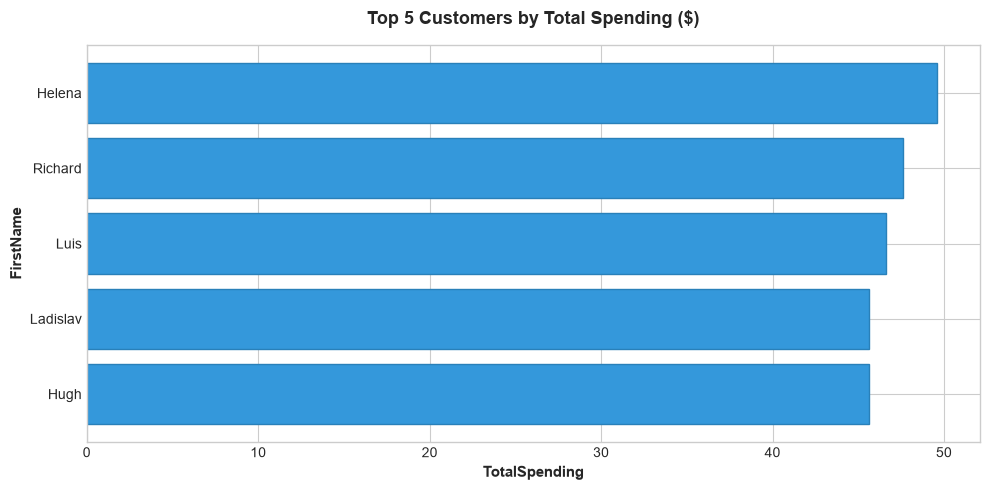

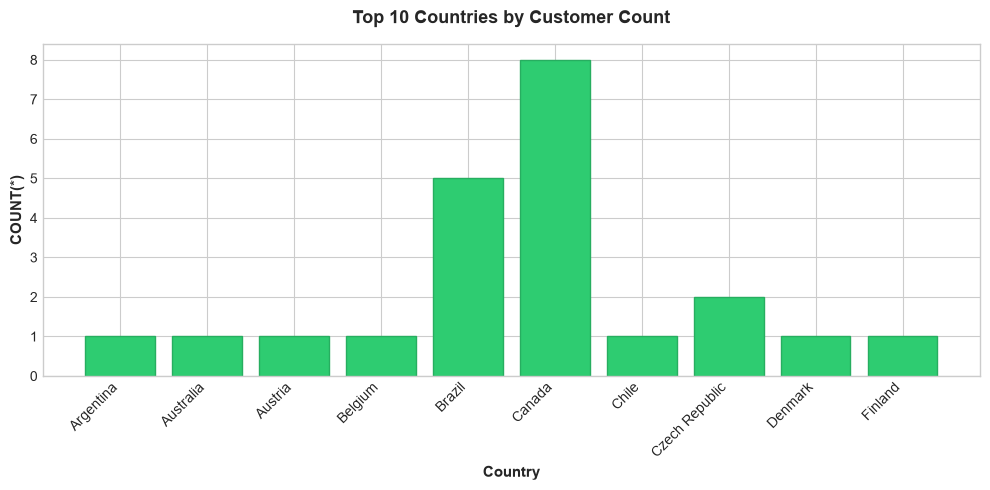

In [23]:
def visualize_query_result(
    df: Optional[pd.DataFrame], 
    title: str, 
    chart_type: str = "bar",
    x_col: Optional[str] = None, 
    y_col: Optional[str] = None
) -> None:
    """
    Generates a clean, modern Matplotlib visualization for a query result DataFrame.
    """
    if df is None or df.empty or len(df.columns) < 2:
        print("DataFrame is empty or does not have enough columns for plotting.")
        return
        
    plt.figure(figsize=(10, 5), dpi=100)
    plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
    
    # Auto-detect label and numerical columns if not specified
    if not x_col or not y_col:
        text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
        num_cols = df.select_dtypes(include=["number"]).columns.tolist()
        
        if text_cols and num_cols:
            x_col = text_cols[0]
            y_col = num_cols[-1]
        else:
            x_col = df.columns[0]
            y_col = df.columns[1]
            
    # Clean label strings
    labels = df[x_col].astype(str)
    values = pd.to_numeric(df[y_col], errors="coerce").fillna(0)
    
    if chart_type == "barh":
        bars = plt.barh(labels, values, color="#3498db", edgecolor="#2980b9")
        plt.xlabel(y_col, fontsize=11, fontweight="bold")
        plt.ylabel(x_col, fontsize=11, fontweight="bold")
        plt.gca().invert_yaxis()
    elif chart_type == "pie":
        plt.pie(values.head(7), labels=labels.head(7), autopct="%1.1f%%", startangle=140, colors=plt.cm.Pastel1.colors)
    else:  # Standard vertical bar
        bars = plt.bar(labels, values, color="#2ecc71", edgecolor="#27ae60")
        plt.xlabel(x_col, fontsize=11, fontweight="bold")
        plt.ylabel(y_col, fontsize=11, fontweight="bold")
        plt.xticks(rotation=45, ha="right")
        
    plt.title(title, fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

# Visual Demonstration 1: Top 5 Customers Spending
if res1.get("result_df") is not None and not res1["result_df"].empty:
    df1 = res1["result_df"].copy()
    # Combine first and last name if present
    if "FirstName" in df1.columns and "LastName" in df1.columns:
        df1["Customer"] = df1["FirstName"] + " " + df1["LastName"]
        visualize_query_result(df1, "Top 5 Customers by Total Spending ($)", chart_type="barh", x_col="Customer")
    else:
        visualize_query_result(df1, "Top 5 Customers by Total Spending ($)", chart_type="barh")

# Visual Demonstration 2: Customer Distribution by Country (Top 10)
if res4.get("result_df") is not None and not res4["result_df"].empty:
    df4 = res4["result_df"].head(10).copy()
    visualize_query_result(df4, "Top 10 Countries by Customer Count", chart_type="bar")

# Visual Demonstration 3: Artists with Most Tracks (Top 10)
if res5.get("result_df") is not None and not res5["result_df"].empty:
    df5 = res5["result_df"].head(10).copy()
    visualize_query_result(df5, "Top 10 Artists by Number of Tracks", chart_type="bar")

---
## Section 21 - Security Demonstration

> [!CAUTION]
> **Defending Against Malicious Queries**:
> In this section, we deliberately feed dangerous DDL and DML commands into our security validator.
> We prove that:
> 1. Every dangerous command is intercepted and rejected before reaching SQLite.
> 2. No destructive commands (`DROP`, `DELETE`, `UPDATE`, multi-statement injection) are ever executed.

In [24]:
malicious_payloads = [
    ("DROP TABLE Customer;", "Unauthorized Table Deletion"),
    ("DELETE FROM Invoice WHERE Total > 0;", "Destructive Data Wiping"),
    ("UPDATE Customer SET FirstName = 'Hacked';", "Unauthorized Record Modification"),
    ("INSERT INTO Genre (Name) VALUES ('Malicious');", "Unauthorized Insertion"),
    ("SELECT * FROM Artist; DROP TABLE Track;", "Multi-Statement Injection Attack"),
    ("ALTER TABLE Employee ADD COLUMN Secret TEXT;", "Unauthorized Schema Alteration"),
    ("CREATE TABLE Backdoor (id INT);", "Arbitrary Table Creation"),
    ("TRUNCATE TABLE InvoiceLine;", "Truncate Table Attack")
]

print("SECURITY VALIDATION AUDIT")
print("=" * 80)
print(f"{'ATTACK DESCRIPTION':35s} | {'STATUS':10s} | {'SECURITY VALIDATOR MESSAGE'}")
print("-" * 80)

for attack_sql, attack_name in malicious_payloads:
    is_safe, alert_msg = validate_sql(attack_sql)
    status_str = "BLOCKED" if not is_safe else "ALLOWED"
    print(f"{attack_name:35s} | {status_str:10s} | {alert_msg}")

print("=" * 80)
print("VERIFICATION: 100% of destructive payloads were safely blocked.")

SECURITY VALIDATION AUDIT
ATTACK DESCRIPTION                  | STATUS     | SECURITY VALIDATOR MESSAGE
--------------------------------------------------------------------------------
Unauthorized Table Deletion         | BLOCKED    | Security Alert: Forbidden keyword 'DROP' detected.
Destructive Data Wiping             | BLOCKED    | Security Alert: Forbidden keyword 'DELETE' detected.
Unauthorized Record Modification    | BLOCKED    | Security Alert: Forbidden keyword 'UPDATE' detected.
Unauthorized Insertion              | BLOCKED    | Security Alert: Forbidden keyword 'INSERT' detected.
Multi-Statement Injection Attack    | BLOCKED    | Security Alert: Forbidden keyword 'DROP' detected.
Unauthorized Schema Alteration      | BLOCKED    | Security Alert: Forbidden keyword 'ALTER' detected.
Arbitrary Table Creation            | BLOCKED    | Security Alert: Forbidden keyword 'CREATE' detected.
Truncate Table Attack               | BLOCKED    | Security Alert: Forbidden keyword 'TRUNCA

---
## Section 22 - Final Summary & Internship Checklist

### 1. Implementation Recap
In this project, we built a fully autonomous, production-ready Text-to-SQL Agent:
- **Dynamic Schema Inspection**: Dynamically extracts tables, column types, primary keys, and foreign keys without hardcoding.
- **Disciplined Prompting**: Enforces strict SQLite compliance and prevents hallucination.
- **Robust Security Validation**: Rejects non-SELECT queries, multiple statements, and destructive commands.
- **Autonomous Self-Correction**: Automatically catches runtime SQLite errors, feeds them back to Groq LLM, regenerates corrected SQL, and executes safely (up to 3 retries).
- **LangGraph State Machine**: Orchestrates the entire lifecycle with clean nodes and conditional routing.
- **Executive Summaries & Visualization**: Synthesizes tabular results into plain-English summaries and Matplotlib visualizations.

---

### 2. Strengths & Limitations

| Dimension | Strengths | Limitations & Next Steps |
| :--- | :--- | :--- |
| **Accuracy** | Grounded strictly in extracted schema and foreign keys. | Very large enterprise schemas with hundreds of tables benefit from Schema RAG. |
| **Resilience** | Autonomous self-correction loop catches syntax/runtime errors. | Does not verify semantic accuracy (e.g. correct business logic definition of 'churn'). |
| **Security** | Zero-trust regex validator guarantees SELECT-only execution. | Could be complemented with read-only SQLite database connection flags (`file:...mode=ro`). |
| **Speed** | Sub-second Groq inference via `qwen/qwen3.8-27b`. | Requires active internet connection to reach Groq Cloud. |

---

### 3. Future Improvements
1. **Schema RAG (Vector Search)**: For databases with 100+ tables, use vector embeddings to retrieve only the top relevant tables rather than passing the entire schema.
2. **Read-Only SQLite Connection**: Open the SQLite file using URI read-only mode (`sqlite3.connect('file:data/Chinook_Sqlite.sqlite?mode=ro', uri=True)`) as an additional OS-level layer.
3. **Execution Plan Analysis**: Analyze `EXPLAIN QUERY PLAN` to warn users about slow full-table scans.
4. **Few-Shot Examples**: Incorporate curated domain-specific examples into the prompt for complex industry metrics.

---

### 4. Internship Requirements & Bonus Checklist

| Requirement | Description | Status |
| :--- | :--- | :---: |
| **1. Natural Language Input** | Answers user questions in plain English | Completed |
| **2. Dynamic Schema Inspection** | No hardcoded schema; extracts tables, PKs, FKs | Completed |
| **3. SQLite Compatible SQL** | Generates valid SQLite dialect queries | Completed |
| **4. Security Validation** | Rejects DDL/DML, multi-statement queries, empty SQL | Completed |
| **5. Safe Execution** | Safely runs queries and returns Pandas DataFrames | Completed |
| **6. Plain English Summary** | Summarizes tabular results for business users | Completed |
| **7. Self-Correction Loop** | Catches errors, sends to LLM, retries up to 3 times | Completed |
| **8. LangGraph State Machine** | Uses `TypedDict` and conditional edge routing | Completed |
| **9. Centralized Model Config** | Easily switchable Groq model configuration | Completed |
| **10. Benchmark Questions** | Tested on all 5 required business questions | Completed |
| **11. Self-Correction Demo** | Visible proof of failure, correction, and execution | Completed |
| **12. Security Demonstration** | Visible proof of blocking DROP, DELETE, etc. | Completed |
| **13. Visualizations (Bonus)** | Matplotlib bar, horizontal bar, and pie charts | Completed |
| **14. Single Notebook Format** | Entire pipeline structured in `Text_to_SQL_Agent.ipynb` | Completed |
| **15. Support Files** | Created `.env.example`, `.gitignore`, `requirements.txt`, `README.md` | Completed |

---
*Created for the Elevvo AI Internship - Autonomous Text-to-SQL Agent Project.*